# Evaluate Model Performance



## Regional Model Preparation

In [4]:
from pathlib import Path
import argparse

import torch
from neuralhydrology.nh_run import start_run

def main():
    # Define the command-line arguments
    parser = argparse.ArgumentParser(description='Run the model training with a specified config file.')
    parser.add_argument('--config', type=str, required=True, help='Path to the config file')

    # Parse the arguments
    args = parser.parse_args()

    # Use the provided config file path
    config_file_path = Path(args.config)

    # Start the run with the specified config file
    start_run(config_file=config_file_path)

if __name__ == "__main__":
    # main()
    start_run(config_file=Path('config.yml'))

2025-05-04 21:32:00,001: Logging to c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159\output.log initialized.
2025-05-04 21:32:00,001: ### Folder structure created at c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159
2025-05-04 21:32:00,003: ### Run configurations for EA-LSTM_Regional
2025-05-04 21:32:00,003: experiment_name: EA-LSTM_Regional
2025-05-04 21:32:00,004: run_dir: c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159
2025-05-04 21:32:00,004: train_basin_file: basin_list\regional_train.txt
2025-05-04 21:32:00,005: validation_basin_file: basin_list\regional_test.txt
2025-05-04 21:32:00,005: test_basin_file: basin_list\regional_test.txt
2025-05-04 21:32:00,005: train_start_date: 2005-01-01 00:00:00
2025-05-04 21:32:00,005: train_end_date: 2023-12-31 00:00:00
2025-05-04 21:32:00,006: validation_start_date: 2005-01-01 00:00:00
2025-05-04 21:32:00,006: validation_end_date: 2023-12

TypeError: '<' not supported between instances of 'str' and 'Timestamp'

## Import Evaluator Module

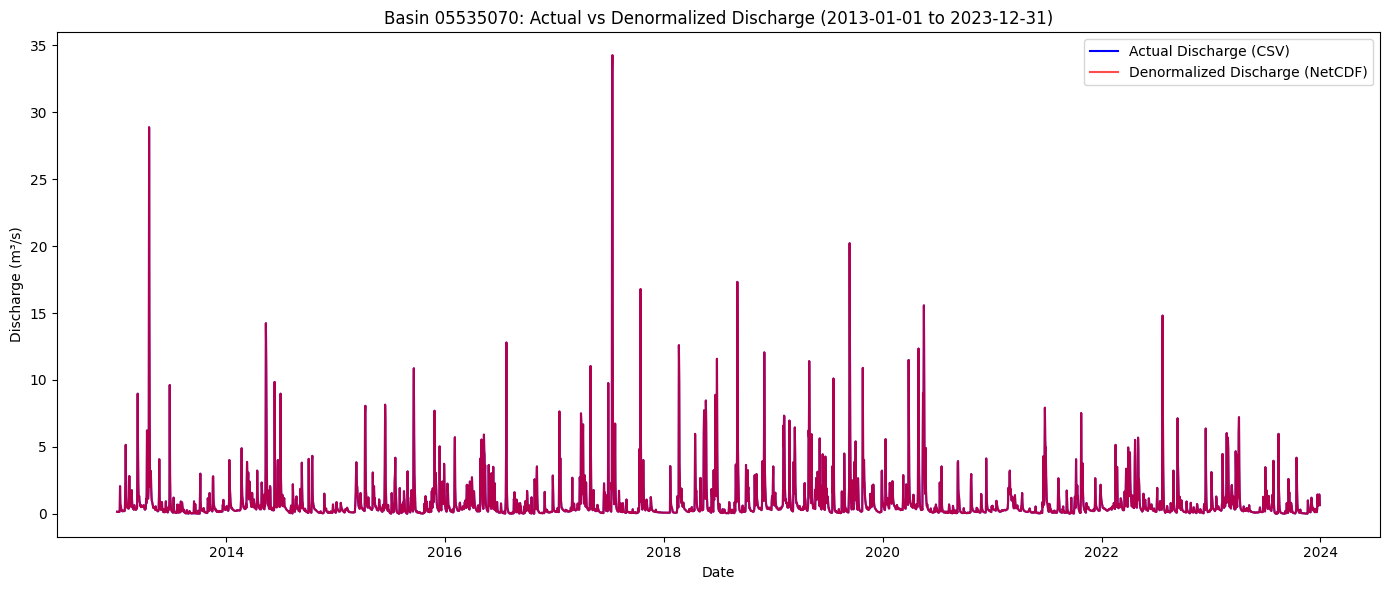

In [14]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BASIN_ID = '05535070'  # <-- Change this to your basin of interest
CSV_DIR = 'metadata/csv_filtered'
NC_DIR = 'data/time_series'
ATTR_FILE = 'metadata/attributes.csv'
EPSILON = 1e-6
BASIN_AREA_SCALE_DIVISOR = 1000.0
TEST_START_DATE = '2013-01-01'

# Load attributes
attributes_df = pd.read_csv(ATTR_FILE)
attributes_df.set_index('gauge_id', inplace=True)
basin_area = attributes_df.loc[BASIN_ID, 'area']
scaled_basin_area = basin_area / BASIN_AREA_SCALE_DIVISOR

# Use your known global mean/std
global_mean = -11.6949
global_std = 67.8412

# Load NetCDF and CSV
nc_path = os.path.join(NC_DIR, f"{BASIN_ID}.nc")
csv_path = os.path.join(CSV_DIR, f"{BASIN_ID}.csv")
ds = xr.open_dataset(nc_path)
df_nc = ds.to_dataframe().reset_index()
ds.close()
df_csv = pd.read_csv(csv_path, parse_dates=['date'])

# Only compare test period
mask = (df_nc['date'] >= TEST_START_DATE)
df_nc = df_nc[mask].copy()
df_csv = df_csv[df_csv['date'] >= TEST_START_DATE].copy()

# Align by date
df_nc = df_nc.set_index('date')
df_csv = df_csv.set_index('date')
common_dates = df_nc.index.intersection(df_csv.index)
df_nc = df_nc.loc[common_dates]
df_csv = df_csv.loc[common_dates]

# Reverse normalization for discharge
sim = df_nc['discharge'].copy()
sim = (sim * global_std) + global_mean
sim = sim * scaled_basin_area
sim = np.exp(sim) - EPSILON

# Prepare for plotting
actual = df_csv['discharge'].copy()
dates = common_dates

plt.figure(figsize=(14, 6))
plt.plot(dates, actual, label='Actual Discharge (CSV)', color='blue')
plt.plot(dates, sim, label='Denormalized Discharge (NetCDF)', color='red', alpha=0.7)
plt.title(f'Basin {BASIN_ID}: Actual vs Denormalized Discharge (2013-01-01 to 2023-12-31)')
plt.xlabel('Date')
plt.ylabel('Discharge (m³/s)')
plt.legend()
plt.tight_layout()
plt.show()

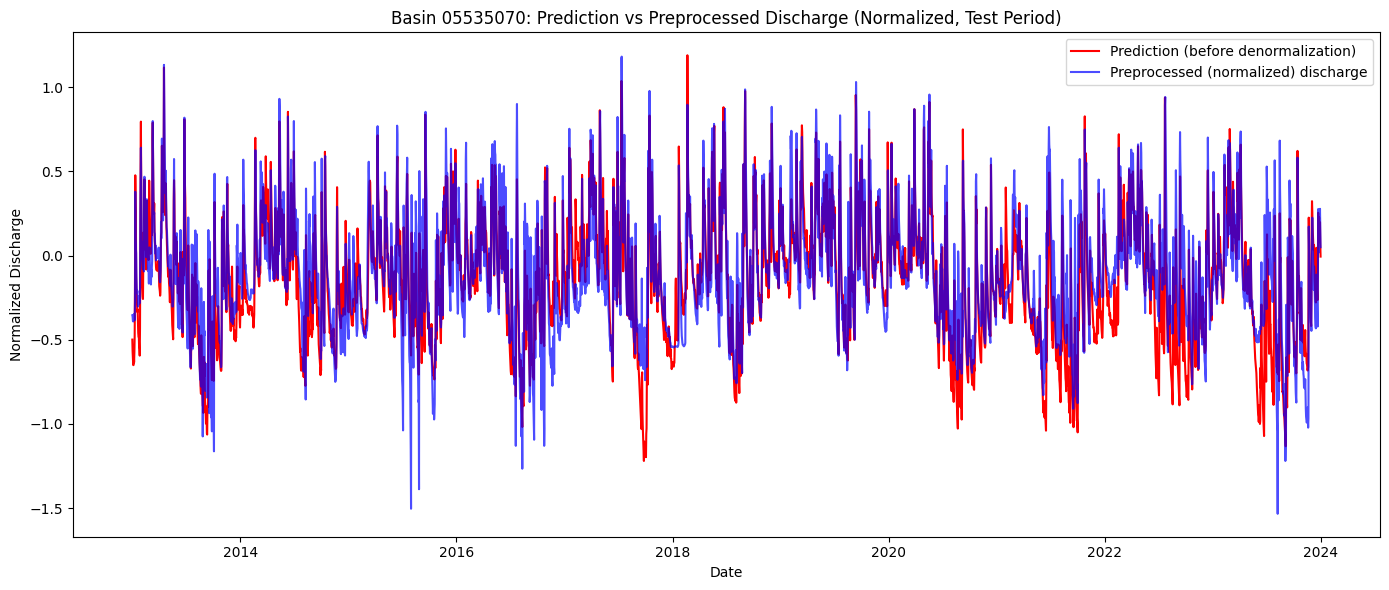

In [16]:
import pickle
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
run_dir = "runs/EA-LSTM_Basin_Normalized_1906_122616"  # <-- Change to your run directory
epoch_num = 42                  # <-- Change to your epoch number
basin_id = '05535070'              # <-- Change to your basin ID
nc_dir = 'data/time_series'
test_start_date = '2013-01-01'
test_end_date = '2023-12-31'

# --- 1. Load predictions (before denormalization) ---
# Find the correct epoch folder
epoch_folder_name = f"model_epoch{epoch_num:03d}"
results_file = Path(run_dir) / "test" / epoch_folder_name / "test_results.p"
if not results_file.exists():
    raise FileNotFoundError(f"Could not find test_results.p at {results_file}")

with open(results_file, "rb") as fp:
    results = pickle.load(fp)

qsim = results[basin_id]['1D']['xr']['discharge_sim']
sim_pred = qsim.values.copy()  # This is BEFORE denormalization
dates_pred = pd.to_datetime(qsim['date'].values)

# --- 2. Load preprocessed (normalized) discharge from NetCDF ---
nc_path = Path(nc_dir) / f"{basin_id}.nc"
ds = xr.open_dataset(nc_path)
df_nc = ds.to_dataframe().reset_index()
ds.close()

# Only test period
mask = (df_nc['date'] >= test_start_date) & (df_nc['date'] <= test_end_date)
df_nc = df_nc[mask].copy()
df_nc = df_nc.set_index('date')

# --- 3. Align by date ---
df_pred = pd.DataFrame({
    'date': np.array(dates_pred).flatten(),
    'predicted': np.array(sim_pred).flatten()
})
df_pred = df_pred[(df_pred['date'] >= test_start_date) & (df_pred['date'] <= test_end_date)]
df_pred = df_pred.set_index('date')

common_dates = df_pred.index.intersection(df_nc.index)
pred_aligned = df_pred.loc[common_dates, 'predicted']
nc_aligned = df_nc.loc[common_dates, 'discharge']

# --- 4. Plot ---
plt.figure(figsize=(14, 6))
plt.plot(common_dates, pred_aligned, label='Prediction (before denormalization)', color='red')
plt.plot(common_dates, nc_aligned, label='Preprocessed (normalized) discharge', color='blue', alpha=0.7)
plt.title(f'Basin {basin_id}: Prediction vs Preprocessed Discharge (Normalized, Test Period)')
plt.xlabel('Date')
plt.ylabel('Normalized Discharge')
plt.legend()
plt.tight_layout()
plt.show()

## Load Model

In [1]:
from util.Evaluator import Evaluator
import pandas as pd

model_dir = "EA-LSTM_Basin_Normalized_1906_122616" # Specify the model name
epoch_num = 39 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/complete_basin_list.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=-11.6949,
                      var=67.8412 ** 2,
                      apply_transformation=True,
                      attributes_file="metadata/attributes.csv")

print(evaluator)

  0%|          | 0/975 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/975 [00:00<02:45,  5.88it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\n

Summary for: evaluate EA-LSTM_Basin_Normalized_1906_122616 epoch 39

NSE Summary Statistics: 
count    6.470000e+02
mean    -7.934228e+03
std      1.506387e+05
min     -3.779002e+06
25%     -6.349355e+00
50%      2.268556e-01
75%      4.841636e-01
max      7.895205e-01
Name: NSE, dtype: float64

KGE Summary Statistics: 
count     647.000000
mean      -13.667687
std        84.769946
min     -1907.352155
25%        -1.034528
50%         0.246046
75%         0.522090
max         0.866738
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
N/A               328
Negative          258
Good              244
Unsatisfactory    138
Excellent           7
Name: count, dtype: int64

evaluate EA-LSTM_Basin_Normalized_1906_122616 epoch 39


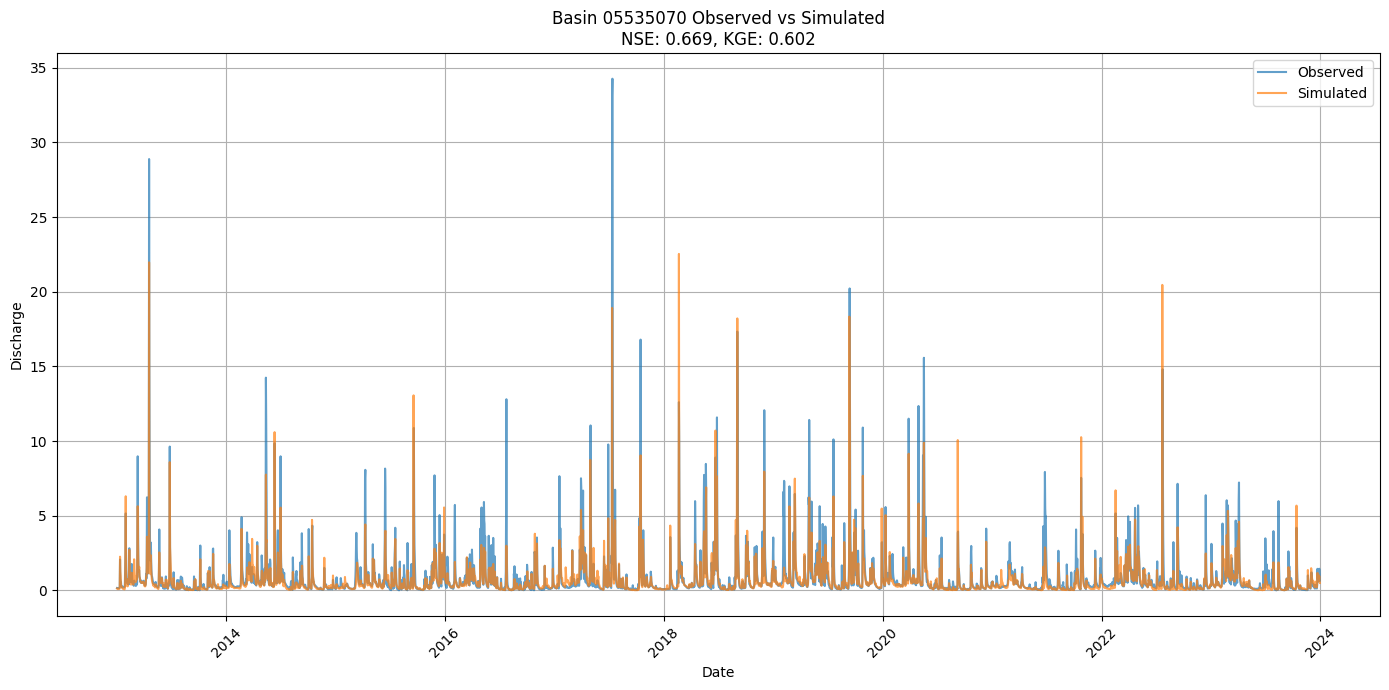

In [2]:
evaluator.plot_prediction("05535070")

In [8]:
results = evaluator.get_metrics()

In [10]:
results.to_csv("basin_normalized_result.csv")

## Plot the validation curve to possibly identify overfitting

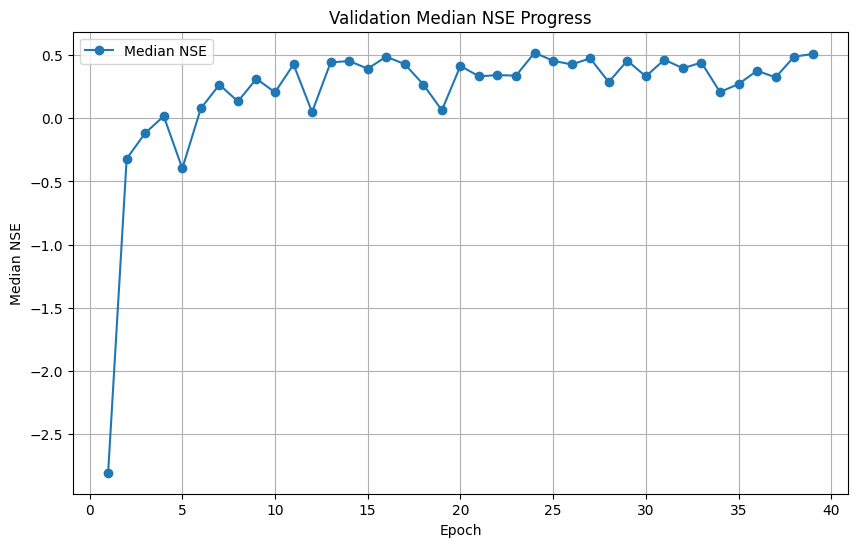

In [3]:
evaluator.plot_validation("Median")

In [4]:
evaluator.get_validation()

,epoch,mean_nse,median_nse,max_nse,mean_kge,median_kge,max_kge
0,1,-165.268435,-2.808597,0.593420,NaN,NaN,NaN
1,2,-19.496370,-0.320170,0.643144,NaN,NaN,NaN
2,3,-28.700061,-0.116735,0.692161,NaN,NaN,NaN
3,4,-11.664238,0.017068,0.685750,NaN,NaN,NaN
4,5,-21.131249,-0.397330,0.680105,NaN,NaN,NaN
5,6,-16.851563,0.078299,0.748472,NaN,NaN,NaN
6,7,-24.464153,0.266782,0.687129,NaN,NaN,NaN
7,8,-16.778951,0.133825,0.803384,NaN,NaN,NaN
8,9,-66.079981,0.313554,0.746884,NaN,NaN,NaN
9,10,-23.264781,0.205952,0.829794,NaN,NaN,NaN


## Evaluation Results

In [32]:
print(evaluator)

Summary Statistic: 
count    6.470000e+02
mean    -3.299132e+60
std      8.391736e+61
min     -2.134538e+63
25%      1.839860e-01
50%      5.036016e-01
75%      6.457838e-01
max      8.590568e-01
Name: NSE, dtype: float64

Performance Summary: 
Performance
Negative          455
Good              378
Unsatisfactory    102
Excellent          40
Name: count, dtype: int64

evaluate GAGEii-ALL_Gauges_Filtered_Periodically_eslstm_1303_085231 epoch 17


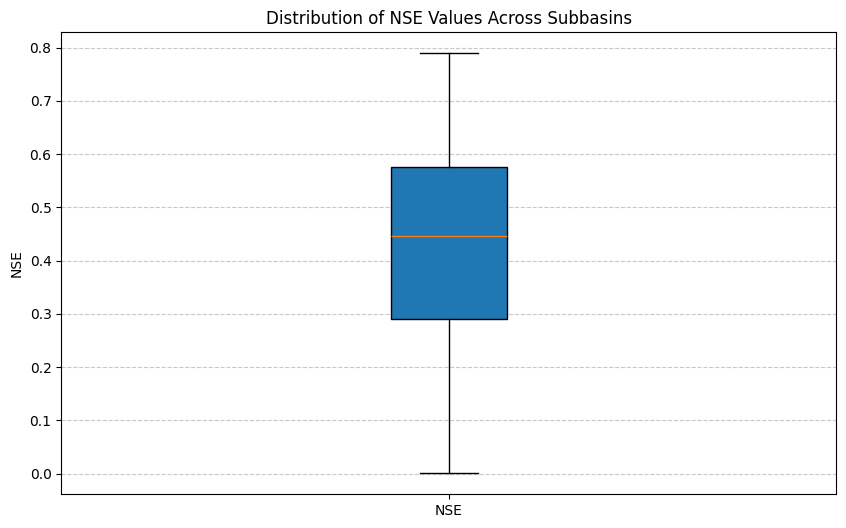

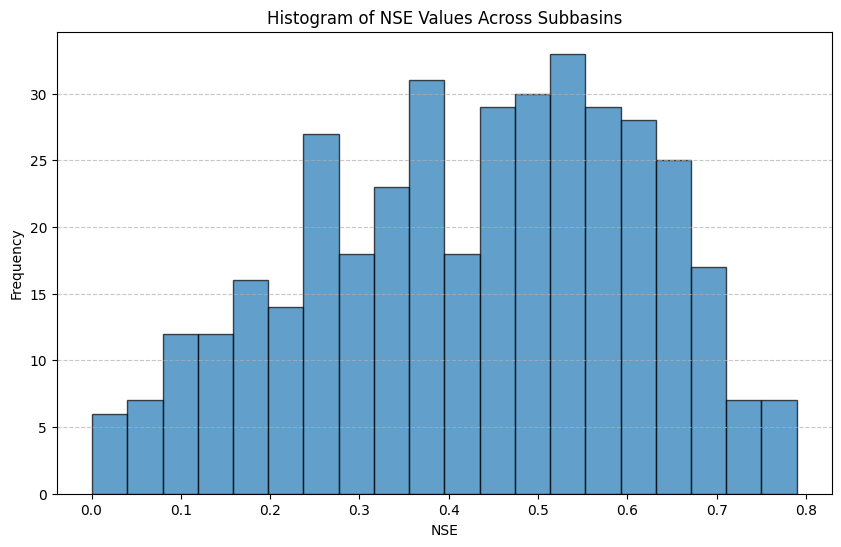

In [5]:
evaluator.plot_nse_distribution()

## Scatterplot of NSE vs Coverage

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

nse_df = evaluator.get_nse()
nse_df_filtered = nse_df[nse_df["NSE"] > 0]
coverage_df = pd.read_csv("metadata/coverage.csv")

# Merge the two dataframes on 'basin_id'
merged_df = pd.merge(nse_df_filtered, coverage_df, on="basin_id", how="inner")

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["discharge_coverage"], merged_df["NSE"], alpha=0.7)
plt.xlabel("Discharge Coverage")
plt.ylabel("NSE")
plt.title("Scatterplot of NSE vs. Discharge Coverage")
plt.grid(True)
plt.show()

AttributeError: 'Evaluator' object has no attribute 'get_nse'

In [7]:
nse_df_filtered.describe()

NameError: name 'nse_df_filtered' is not defined

In [36]:
nse_df.to_csv("result.csv")

## LBRM

In [2]:
from util.Evaluator import Evaluator

model_dir = "EA-LSTM_LowerLearningRate_0404_074727" # Specify the model name
epoch_num = 18 # Specify the epoch number
eval_dir = "metadata/LBRM_daymet" # Directory to the csv files for evaluation
eval_list = "basin_list/LBRM.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=False,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      mean=3.0596,
                      var=1.7268**2,
                      apply_transformation=True,)

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\neuralhydrology\evaluation\tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub f

# Evaluation:   0%|          | 0/107 [00:00<?, ?it/s]

# Evaluation: 100%|██████████| 107/107 [13:07<00:00,  7.36s/it]


  0%|          | 0/107 [00:00<?, ?it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
 10%|█         | 11/107 [00:00<00:03, 31.43it/s]C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\

In [3]:
print(evaluator)

Summary for: evaluate EA-LSTM_LowerLearningRate_0404_074727 epoch 18

NSE Summary Statistics: 
count    89.000000
mean     -0.905510
std       4.733488
min     -44.001761
25%      -0.411956
50%      -0.106489
75%       0.036073
max       0.367395
Name: NSE, dtype: float64

KGE Summary Statistics: 
count    89.000000
mean     -0.257110
std       1.438797
min     -12.864404
25%      -0.230482
50%      -0.019058
75%       0.149761
max       0.523085
Name: KGE, dtype: float64

Performance Summary (based on NSE): 
Performance
Negative          61
Unsatisfactory    27
N/A               18
Good               1
Name: count, dtype: int64

evaluate EA-LSTM_LowerLearningRate_0404_074727 epoch 18


In [ ]:
evaluator.get_metrics()

,basin_id,NSE,KGE,Performance
0,eri01,0.035800,0.063384,Unsatisfactory
1,eri02,-0.720089,0.030211,Negative
2,eri03,NaN,NaN,N/A
3,eri04,-0.007130,0.167309,Negative
4,eri05,-0.083312,0.094049,Negative
...,...,...,...,...
102,sup18,-1.557546,-1.016950,Negative
103,sup19,-7.025992,-0.353388,Negative
104,sup20,-0.013548,-0.146431,Negative
105,sup21,-0.046774,-0.049101,Negative


In [12]:
evaluator.get_prediction("sup18")

(-1.5575455248632073,
 -1.0169499221474823,
 array([43.442146, 42.610622, 42.17928 , ..., 52.57356 , 48.998627,
        49.10012 ], dtype=float32),
 array([ 6.957,  6.836,  6.745, ..., 10.102,  9.558,  9.044]),
 array(['2013-01-01T00:00:00.000000000', '2013-01-02T00:00:00.000000000',
        '2013-01-03T00:00:00.000000000', ...,
        '2023-12-29T00:00:00.000000000', '2023-12-30T00:00:00.000000000',
        '2023-12-31T00:00:00.000000000'], dtype='datetime64[ns]'))

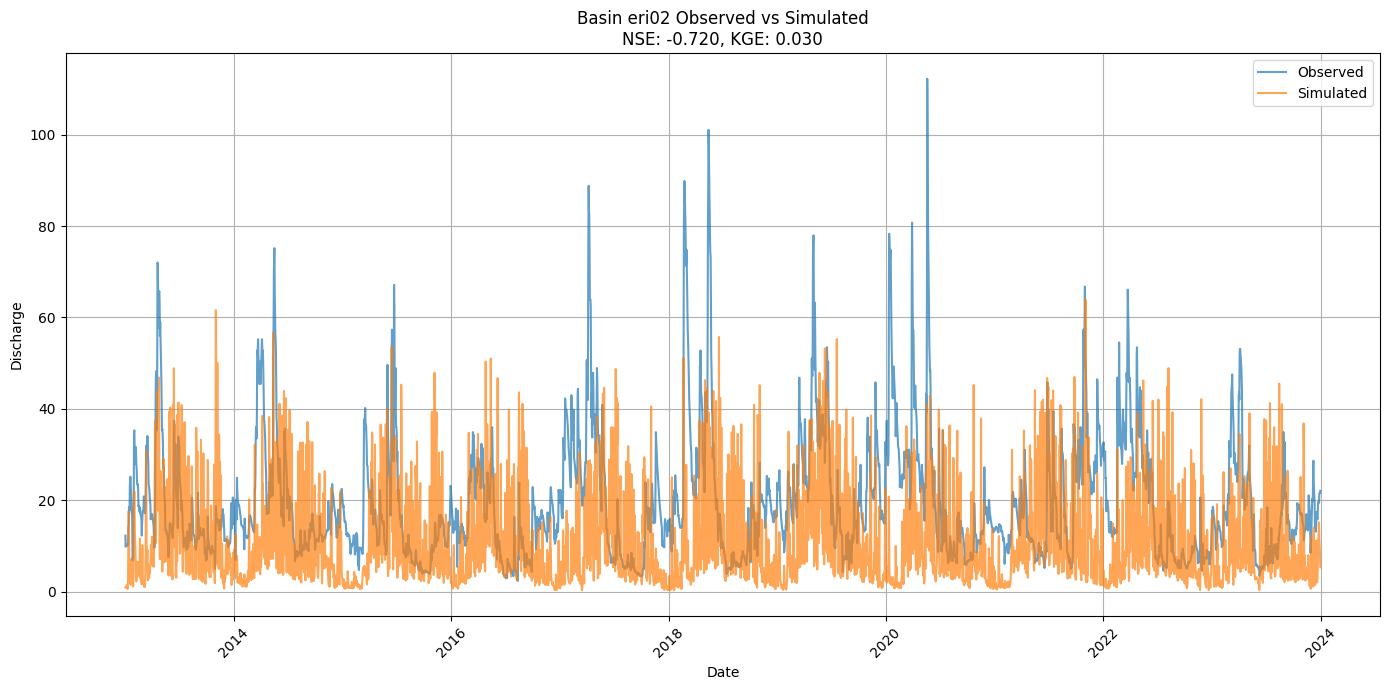

In [14]:
evaluator.plot_prediction("eri02")

In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

csv_dir = Path("metadata/LBRM_daymet")
csv_files = list(csv_dir.glob("*.csv"))

for csv_file in tqdm(csv_files, desc="Renaming 'Date' to 'date' in CSVs"):
    try:
        df = pd.read_csv(csv_file)
        if "Date" in df.columns:
            df.rename(columns={"Date": "date"}, inplace=True)
            df.to_csv(csv_file, index=False)
    except Exception as e:
        print(f"Error processing {csv_file.name}: {e}")

Renaming 'Date' to 'date' in CSVs: 100%|██████████| 121/121 [00:07<00:00, 16.84it/s]
